[[0, 0], [10.97, 0], [10.97, 23.77], [0, 23.77]]
[[0, 11.885], [10.97, 11.885]]
[[5.485, 0], [5.485, 23.77]]
[[1.37, 0], [1.37, 23.77]]
[[9.600000000000001, 0], [9.600000000000001, 23.77]]
[[1.37, 5.484999999999999], [9.600000000000001, 5.484999999999999]]
[[1.37, 18.285], [9.600000000000001, 18.285]]


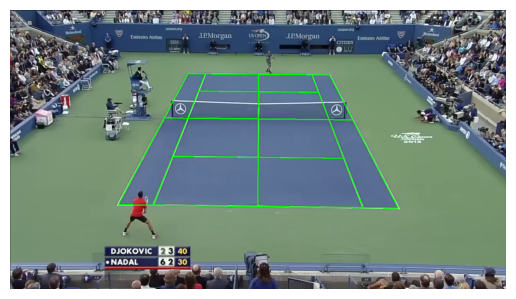

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

court_w = 10.97
court_l = 23.77
singles_sideline = 1.37
sl_to_net = 6.40

# Your clicks (image pixels), order: NL, NR, FR, FL
img_corners = np.float32([
    [279.6, 502.8],
    [1002.4, 511.8],
    [824.7, 167.8],
    [458.3, 164.8],
])

# Singles court in meters (same order)
# width 8.23 m, length 23.77 m
court_corners = np.float32([
    [0, court_l],      # near-left
    [court_w, court_l],   # near-right
    [court_w, 0],       # far-right
    [0, 0],          # far-left
])

# Court plane → image
H = cv2.getPerspectiveTransform(court_corners, img_corners)

def court_to_image(pts_xy):
    print(pts_xy)
    """pts_xy: (N, 2) court coords → (N, 2) image pixels."""
    pts = np.asarray(pts_xy, dtype=np.float32).reshape(-1, 1, 2)
    out = cv2.perspectiveTransform(pts, H)
    return out.reshape(-1, 2)

def draw_court(image_path):
    # Example: outer rectangle + net line
    lines = [
    [[0, 0], [court_w, 0], [court_w, court_l], [0, court_l]],  # baseline rectangle
    [[0, court_l/2], [court_w, court_l/2]], # net
    [[court_w/2, 0], [court_w/2, court_l]], # center line
    [[singles_sideline, 0], [singles_sideline, court_l]], # singles sideline (left)
    [[court_w - singles_sideline, 0], [court_w - singles_sideline, court_l]], # singles sideline (right)
    [[singles_sideline, court_l/2 - sl_to_net], [court_w - singles_sideline, court_l/2 - sl_to_net]], # serving line (opposite side)
    [[singles_sideline, court_l/2 + sl_to_net], [court_w - singles_sideline, court_l/2 + sl_to_net]], # serving line (same side)
]

image = cv2.imread("../debug/frame_0.jpg")
vis = image.copy()
for line in lines:
    pix = court_to_image(line).astype(np.int32)
    cv2.polylines(vis, [pix], isClosed=(len(line) > 2), color=(0, 255, 0), thickness=2)

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()